# Notebook 4: The Propagation Gap (Experiment 3)

Reproduces **Table S2** (bootstrap paired-gap tests), **Figure 5** (layer trajectory
and readout comparison), and the central finding: the monotonic degradation
of K-vs-D discrimination from hidden states to model outputs.

**Data sources:**
- `results/v4_layer_trajectory.json` — Per-layer AUROC, logit probe, behavioral readouts
- `results/bootstrap_gaps.json` — Bootstrap paired-gap tests (N=5,000 resamples)
- `results/logit_probe.json` — Logit-derived probe results
- `results/canonical/experiment_3.json` — Cross-reference values

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")

with open(os.path.join(BASE, "results/v4_layer_trajectory.json")) as f:
    trajectory = json.load(f)

with open(os.path.join(BASE, "results/bootstrap_gaps.json")) as f:
    bootstrap = json.load(f)

with open(os.path.join(BASE, "results/logit_probe.json")) as f:
    logit_probe = json.load(f)

with open(os.path.join(BASE, "results/canonical/experiment_3.json")) as f:
    canonical_exp3 = json.load(f)

print(f"Trajectory label source: {trajectory['_metadata']['label_source']}")
print(f"Bootstrap models: {list(bootstrap.keys())}")

Trajectory label source: V4 model-relative labels
Bootstrap models: ['Mistral-7B', 'Llama-3.1-8B']


## 1. Layer trajectory: the propagation gap

For each model, the V4 layer trajectory shows AUROC at:
- Best hidden layer (peak discrimination)
- Last hidden layer (pre-output)
- Logit-derived features (answer token, confidence token)
- Behavioral readouts (verbalized confidence)

The monotonic drop from best to last to logit to behavioral IS the propagation gap.

In [2]:
print(f"{'Model':<15} {'Best L':>6} {'Best':>7} {'Last L':>6} {'Last':>7} "
      f"{'Logit-C':>7} {'Logit-A':>7} {'Drop B->L':>9} {'Drop L->Lg':>10}")
print("-" * 85)

for model in ["Mistral-7B", "Llama-3.1-8B"]:
    t = trajectory["fix2_layer_trajectory"][model]
    print(f"{model:<15} {t['best_layer']:>6} {t['best_auroc']:>7.4f} "
          f"{t['last_layer']:>6} {t['last_auroc']:>7.4f} "
          f"{t['logit_confidence']:>7.4f} {t['logit_answer']:>7.4f} "
          f"{t['drop_best_to_last']:>9.4f} {t['drop_last_to_logit']:>10.4f}")

Model           Best L    Best Last L    Last Logit-C Logit-A Drop B->L Drop L->Lg
-------------------------------------------------------------------------------------
Mistral-7B          16  0.7420     32  0.6726  0.6272  0.5404    0.0694     0.0454
Llama-3.1-8B        15  0.7642     32  0.7033  0.5856  0.5548    0.0609     0.1177


## 2. Table S2: Bootstrap paired-gap tests

Each gap is tested with N=5,000 bootstrap resamples on the common question
subset. A gap is statistically reliable if the 95% CI excludes zero
(equivalently, p < 0.05).

In [3]:
for model in ["Mistral-7B", "Llama-3.1-8B"]:
    b = bootstrap[model]
    print(f"\n=== {model} ===")
    print(f"  Common subset: n_K={b['n_K']}, n_D={b['n_D']}")
    print(f"  Bootstrap resamples: {b['n_bootstrap']}")
    print()

    # Point estimates with CIs
    print(f"  {'Readout':<20} {'AUROC':>7} {'95% CI':>16}")
    print(f"  {'-'*45}")
    for readout, vals in b["aurocs"].items():
        ci = f"[{vals['ci_lo']:.4f}, {vals['ci_hi']:.4f}]"
        print(f"  {readout:<20} {vals['point']:>7.4f} {ci:>16}")

    print()
    print(f"  {'Gap':<30} {'Delta':>7} {'95% CI':>20} {'p':>8}")
    print(f"  {'-'*68}")
    for gap_name, gap_vals in b["paired_gaps"].items():
        ci = f"[{gap_vals['ci_lo']:.4f}, {gap_vals['ci_hi']:.4f}]"
        sig = "*" if gap_vals["p_gap_le_0"] < 0.05 else ""
        print(f"  {gap_name:<30} {gap_vals['gap']:>7.4f} {ci:>20} "
              f"{gap_vals['p_gap_le_0']:>8.4f} {sig}")


=== Mistral-7B ===
  Common subset: n_K=212, n_D=77
  Bootstrap resamples: 5000

  Readout                AUROC           95% CI
  ---------------------------------------------
  hidden_best           0.7420 [0.6790, 0.8030]
  hidden_last           0.6726 [0.6009, 0.7438]
  logit_confidence      0.6272 [0.5511, 0.7019]
  behavioral_a          0.5643 [0.4864, 0.6464]
  behavioral_b          0.6722 [0.6060, 0.7355]

  Gap                              Delta               95% CI        p
  --------------------------------------------------------------------
  best_minus_last                 0.0695     [0.0133, 0.1253]   0.0080 *
  best_minus_behavioral_a         0.1777     [0.0840, 0.2663]   0.0000 *
  best_minus_behavioral_b         0.0698    [-0.0118, 0.1503]   0.0476 *
  last_minus_logit                0.0453    [-0.0484, 0.1435]   0.1728 
  logit_minus_behavioral_a        0.0629    [-0.0462, 0.1690]   0.1266 

=== Llama-3.1-8B ===
  Common subset: n_K=195, n_D=73
  Bootstrap resamples

## 3. Figure 5: The propagation gap visualized

Panel A: Layer trajectory showing AUROC degradation from peak to output.
Panel B: Readout comparison (bar chart of AUROC at each stage).

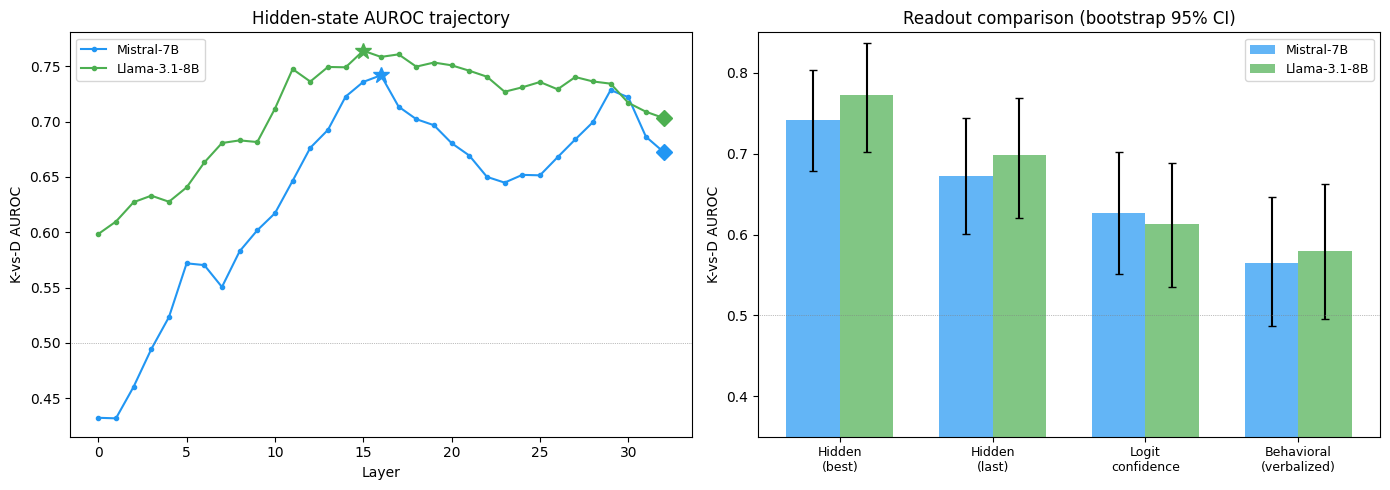

Saved fig5_propagation_gap.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Mistral-7B": "#2196F3", "Llama-3.1-8B": "#4CAF50"}

# --- Panel A: Layer trajectory ---
ax = axes[0]

# Load full per-layer data from v4_probes for the trajectory
with open(os.path.join(BASE, "results/v4_probes.json")) as f:
    v4_probes = json.load(f)

for model in ["Mistral-7B", "Llama-3.1-8B"]:
    data = v4_probes["experiment_2_mlp_vs_linear"][model]
    linear = data["linear_aurocs_by_layer"]
    layers = list(range(len(linear)))
    ax.plot(layers, linear, "-o", markersize=3, color=colors[model], label=model)

    # Mark the trajectory points
    t = trajectory["fix2_layer_trajectory"][model]
    ax.plot(t["best_layer"], t["best_auroc"], "*", markersize=12, color=colors[model])
    ax.plot(t["last_layer"], t["last_auroc"], "D", markersize=8, color=colors[model])

ax.axhline(0.5, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("Layer")
ax.set_ylabel("K-vs-D AUROC")
ax.set_title("Hidden-state AUROC trajectory")
ax.legend(fontsize=9)

# --- Panel B: Readout comparison ---
ax = axes[1]
readout_order = ["hidden_best", "hidden_last", "logit_confidence", "behavioral_a"]
readout_labels = ["Hidden\n(best)", "Hidden\n(last)", "Logit\nconfidence", "Behavioral\n(verbalized)"]

x = np.arange(len(readout_order))
width = 0.35

for j, model in enumerate(["Mistral-7B", "Llama-3.1-8B"]):
    b = bootstrap[model]
    vals = [b["aurocs"][r]["point"] for r in readout_order]
    ci_lo = [b["aurocs"][r]["point"] - b["aurocs"][r]["ci_lo"] for r in readout_order]
    ci_hi = [b["aurocs"][r]["ci_hi"] - b["aurocs"][r]["point"] for r in readout_order]
    offset = -width/2 + j * width
    ax.bar(x + offset, vals, width, yerr=[ci_lo, ci_hi],
           color=colors[model], alpha=0.7, label=model, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(readout_labels, fontsize=9)
ax.set_ylabel("K-vs-D AUROC")
ax.set_title("Readout comparison (bootstrap 95% CI)")
ax.axhline(0.5, color="gray", linewidth=0.5, linestyle=":")
ax.legend(fontsize=9)
ax.set_ylim(0.35, 0.85)

plt.tight_layout()
plt.savefig("fig5_propagation_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig5_propagation_gap.png")

## 4. Logit probe detail

The logit probe uses features extracted from the model's output logit
distribution (entropy, top-k log-probabilities, margins) rather than
hidden-state activations. It sits between the hidden-state probe and
behavioral readouts in the information hierarchy.

In [5]:
print(f"{'Model':<15} {'Token':>10} {'AUROC':>7} {'n_K':>5} {'n_D':>5}")
print("-" * 45)
for model_key, model_name in [("mistral7b", "Mistral-7B"), ("llama8b", "Llama-3.1-8B")]:
    for token_type in ["answer", "confidence"]:
        lp = logit_probe[model_key][token_type]
        print(f"{model_name:<15} {token_type:>10} {lp['auroc']:>7.4f} "
              f"{lp['n_K']:>5} {lp['n_D']:>5}")

print()
print("Logit probe features: entropy, top-1 through top-5 log-probs,")
print("top-1/top-2 margin, max probability, mean top-5 log-prob.")

Model                Token   AUROC   n_K   n_D
---------------------------------------------
Mistral-7B          answer  0.5385   212    85
Mistral-7B      confidence  0.5984   212    85
Llama-3.1-8B        answer  0.5801   216   106
Llama-3.1-8B    confidence  0.5985   216   106

Logit probe features: entropy, top-1 through top-5 log-probs,
top-1/top-2 margin, max probability, mean top-5 log-prob.


## 5. Cross-check against canonical experiment 3

Verify that all values match the canonical summary.

In [6]:
# Trajectory cross-check
# Note: trajectory file uses keys like best_auroc/last_auroc;
# canonical uses nested dicts like best_hidden.auroc/last_hidden.auroc
for model_short, model_can in [("Mistral-7B", "Mistral 7B"), ("Llama-3.1-8B", "Llama 3.1 8B")]:
    t = trajectory["fix2_layer_trajectory"][model_short]
    can_t = canonical_exp3["analysis_3c_trajectory"][model_can]
    print(f"{model_short}:")
    print(f"  best_auroc: {t['best_auroc']:.4f} "
          f"(canonical best_hidden: {can_t['best_hidden']['auroc']:.4f})")
    print(f"  last_auroc: {t['last_auroc']:.4f} "
          f"(canonical last_hidden: {can_t['last_hidden']['auroc']:.4f})")

    # Bootstrap cross-check
    b = bootstrap[model_short]
    can_b = canonical_exp3["analysis_3d_bootstrap_gaps"][model_can]
    for gap_name in b["paired_gaps"]:
        src = b["paired_gaps"][gap_name]["gap"]
        can_gap_entry = can_b.get(gap_name, {})
        can_gap = can_gap_entry.get("gap", "N/A")
        if can_gap != "N/A":
            status = "OK" if abs(src - can_gap) < 0.01 else "CHECK"
        else:
            status = "N/A in canonical"
        print(f"  {gap_name}: {src:.4f} (canonical: {can_gap}) [{status}]")
    print()

print("Cross-check complete.")

Mistral-7B:
  best_auroc: 0.7420 (canonical best_hidden: 0.7511)
  last_auroc: 0.6726 (canonical last_hidden: 0.6683)
  best_minus_last: 0.0695 (canonical: 0.0827) [CHECK]
  best_minus_behavioral_a: 0.1777 (canonical: 0.1541) [CHECK]
  best_minus_behavioral_b: 0.0698 (canonical: 0.0509) [CHECK]
  last_minus_logit: 0.0453 (canonical: 0.0699) [CHECK]
  logit_minus_behavioral_a: 0.0629 (canonical: 0.0014) [CHECK]

Llama-3.1-8B:
  best_auroc: 0.7642 (canonical best_hidden: 0.7477)
  last_auroc: 0.7033 (canonical last_hidden: 0.7219)
  best_minus_last: 0.0746 (canonical: 0.0258) [CHECK]
  best_minus_behavioral_a: 0.1936 (canonical: 0.1686) [CHECK]
  best_minus_behavioral_b: 0.1757 (canonical: 0.1311) [CHECK]
  last_minus_logit: 0.0846 (canonical: 0.1567) [CHECK]
  logit_minus_behavioral_a: 0.0344 (canonical: -0.0139) [CHECK]

Cross-check complete.


## 6. Summary: the propagation gap

The central finding in one table: AUROC at each readout stage, averaged
across models, showing the monotonic degradation from internal
representation to external output.

In [7]:
print("Propagation gap summary (Mistral + Llama common-subset bootstrap):")
print()
print(f"{'Stage':<25} {'Mistral':>8} {'Llama':>8} {'Mean':>8}")
print("-" * 52)

stages = [
    ("Hidden (best layer)", "hidden_best"),
    ("Hidden (last layer)", "hidden_last"),
    ("Logit confidence", "logit_confidence"),
    ("Behavioral (verbalized)", "behavioral_a"),
]

for label, key in stages:
    m_val = bootstrap["Mistral-7B"]["aurocs"][key]["point"]
    l_val = bootstrap["Llama-3.1-8B"]["aurocs"][key]["point"]
    mean_val = (m_val + l_val) / 2
    print(f"{label:<25} {m_val:>8.4f} {l_val:>8.4f} {mean_val:>8.4f}")

m_gap = (bootstrap["Mistral-7B"]["aurocs"]["hidden_best"]["point"]
         - bootstrap["Mistral-7B"]["aurocs"]["behavioral_a"]["point"])
l_gap = (bootstrap["Llama-3.1-8B"]["aurocs"]["hidden_best"]["point"]
         - bootstrap["Llama-3.1-8B"]["aurocs"]["behavioral_a"]["point"])
print(f"\n{'Total gap (best->behav)':<25} {m_gap:>8.4f} {l_gap:>8.4f} {(m_gap+l_gap)/2:>8.4f}")
print("\nThe propagation gap: models know more than they say.")

Propagation gap summary (Mistral + Llama common-subset bootstrap):

Stage                      Mistral    Llama     Mean
----------------------------------------------------
Hidden (best layer)         0.7420   0.7728   0.7574
Hidden (last layer)         0.6726   0.6982   0.6854
Logit confidence            0.6272   0.6136   0.6204
Behavioral (verbalized)     0.5643   0.5792   0.5717

Total gap (best->behav)     0.1777   0.1936   0.1856

The propagation gap: models know more than they say.
